In [4]:
#adapted from https://github.com/aweitz/EveryNoise/blob/master/scrapGenres.ipynb
from bs4 import BeautifulSoup
import requests, sys
import pandas as pd
import numpy as np
import os
import re
import time
import resource
from urllib3.util.retry import Retry

# Parallel and Multiprocessing Packages
from threading import get_ident
from multiprocessing import cpu_count
import asyncio
from concurrent.futures import ThreadPoolExecutor as PoolExecuter

from joblib.externals.loky import set_loky_pickler
from joblib import parallel_backend, Parallel, delayed, wrap_non_picklable_objects

# Custom Scripts
direc = sys.path.insert(1, '..')
from misc_tools.data_tools import chunkIt 

In [5]:
r = requests.get("http://everynoise.com/engenremap.html")
resource.setrlimit(resource.RLIMIT_NOFILE, (65536,resource.RLIM_INFINITY))

session = requests.Session()

retry_strategy = Retry(
    total=5,  # Total number of retries
    backoff_factor=1,  # Waits 1 second between retries, then 2s, 4s, 8s...
    status_forcelist=[429, 500, 502, 503, 504],  # Status codes to retry on
    # method_whitelist=["HEAD", "GET", "OPTIONS"]  # Methods to retry
)

adapter = requests.adapters.HTTPAdapter(max_retries=retry_strategy)
session.mount("http://", adapter)
session.mount("https://", adapter)

In [6]:
@wrap_non_picklable_objects
def genre_scraper(subgenre_subset):
    # Metadata
    subgenre_list_artist = []
    subgenre_list_opp = []
    subgenre_list_sim = []
    subgenre_list = []
    playlists = []
    sim_weights = []
    opp_weights = []
    artist_weights = []

    split_genrecount = 0
    
    # Looping over subgenres to get metadata
    for genreDiv in subgenre_subset:
        subgenre = re.sub(r"[:'+»&\s-]", '', genreDiv)
        
        # Keeps ' and & for the names
        subgenre_name = re.sub(r"[:+»\s]", ' ', genreDiv).strip()
        subgenre_list.append(subgenre_name)
        
        # Printing Genre Name
        sys.stdout.flush()
        print('Pulling genre # {} - Subgenre: {}\n'.format(split_genrecount, subgenre_name))
        sys.stdout.flush()
        
        # Fetch the subgenre
        subgenre_page = 'http://everynoise.com/engenremap-' + subgenre + '.html'
        r2 = session.get(subgenre_page)
        soup2 = BeautifulSoup(r2.text, 'html.parser')

        
        spotify_link = soup2.find_all('a', text = 'playlist')
        playlists.append(spotify_link[0]['href'])
        allArtistDivs = set(soup2.find_all("div", "genre scanme"))
        allGenresRelated = set(soup2.find_all("div", "genre"))
        allGenresRelated = allGenresRelated - allArtistDivs
        
        # Temp Variables
        artist_list = []
        art_w = []
        
        # Get artists associated with the subgenre
        for artist in allArtistDivs:
            weight = artist['style'].split()[-1].replace('%', '')
            artistName = artist.text.strip().replace("»", "")
            if not(artistName.isspace()):
                art_w.append(weight)
                artist_list.append(artistName)
        artist_weights.append(art_w)
        subgenre_list_artist.append(artist_list)
        
        # Temp variables
        weights_sim = []
        weights_opp = []
        opp_genres = []
        sim_genres = []
        
        # Get similar / opposite genres
        for other_genre in allGenresRelated:
            weight = other_genre['style'].split()[-1].replace('%', '')
            if 'nearby' in other_genre['id']:
                g = other_genre.text.strip().replace("»", '')
                if g != subgenre_name:
                    weights_sim.append(weight)
                    sim_genres.append(g)
            elif 'mirror' in other_genre['id']:
                weights_opp.append(weight)
                opp_genres.append(other_genre.text.strip().replace("»", ''))
                
        subgenre_list_sim.append(sim_genres)
        subgenre_list_opp.append(opp_genres)
        sim_weights.append(weights_sim)
        opp_weights.append(weights_opp)
        split_genrecount += 1
    return [subgenre_list, playlists, subgenre_list_sim, sim_weights, subgenre_list_opp, opp_weights, subgenre_list_artist, artist_weights]

In [7]:
def parallel_wrapper(allGenreDivs, n_jobs = cpu_count()):
    subgenre_subsets = chunkIt(allGenreDivs, n_jobs)
    results = Parallel(n_jobs = n_jobs)(delayed(genre_scraper)(subset) for subset in subgenre_subsets)
    res = list(map(list, zip(*results)))
    res_2 = []
    for i in res:
        q = []
        for j in i:
            q += j
        res_2.append(q)
    return(res_2)

In [8]:
soup = BeautifulSoup(r.text,"html.parser")
allGenreDivs = soup.find_all("div", "genre scanme")
agd = []
for i in allGenreDivs:
    agd.append(i.text)
t1 = time.time()
music_data = parallel_wrapper(agd)
t2 = time.time()
print('Time Taken to Gather Data: {:.02f}s'.format(t2-t1))

Pulling genre # 0 - Subgenre: pop

Pulling genre # 0 - Subgenre: deep latin alternative

Pulling genre # 0 - Subgenre: gothenburg metal

Pulling genre # 0 - Subgenre: deep disco house

Pulling genre # 0 - Subgenre: sad lo-fi

Pulling genre # 0 - Subgenre: dutch drill

Pulling genre # 0 - Subgenre: indie cordoba

Pulling genre # 0 - Subgenre: afroswing

Pulling genre # 0 - Subgenre: italian gothic

Pulling genre # 0 - Subgenre: ottawa indie

Pulling genre # 0 - Subgenre: flint hip hop

Pulling genre # 0 - Subgenre: polish folk metal

Pulling genre # 0 - Subgenre: turkish classical performance

Pulling genre # 0 - Subgenre: colombian hardcore

Pulling genre # 0 - Subgenre: deep hardcore punk

Pulling genre # 0 - Subgenre: belgian contemporary classical



/var/folders/k5/qz9qh3jx46dd01ydlzds97900000gn/T/ipykernel_79857/2770495497.py:34: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
/var/folders/k5/qz9qh3jx46dd01ydlzds97900000gn/T/ipykernel_79857/2770495497.py:34: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
/var/folders/k5/qz9qh3jx46dd01ydlzds97900000gn/T/ipykernel_79857/2770495497.py:34: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
/var/folders/k5/qz9qh3jx46dd01ydlzds97900000gn/T/ipykernel_79857/2770495497.py:34: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
/var/folders/k5/qz9qh3jx46dd01ydlzds97900000gn/T/ipykernel_79857/2770495497.py:34: DeprecationWarning: The 'text' argument to find()-type methods is deprecated. Use 'string' instead.
/var/folders/k5/qz9qh3jx46dd01ydlzds97900000gn/T/ipykernel_79857/2770495497.py:34: De

Pulling genre # 1 - Subgenre: rwandan gospel

Pulling genre # 1 - Subgenre: italian gothic metal

Pulling genre # 1 - Subgenre: trot

Pulling genre # 1 - Subgenre: classical mandolin

Pulling genre # 1 - Subgenre: oakland hip hop

Pulling genre # 1 - Subgenre: solomon islands pop

Pulling genre # 1 - Subgenre: kantele

Pulling genre # 1 - Subgenre: horror punk brasileiro

Pulling genre # 1 - Subgenre: icelandic experimental

Pulling genre # 1 - Subgenre: russian nu metal

Pulling genre # 1 - Subgenre: nordic folk

Pulling genre # 1 - Subgenre: dmv rap

Pulling genre # 1 - Subgenre: munich electronic

Pulling genre # 1 - Subgenre: livetronica

Pulling genre # 1 - Subgenre: rap

Pulling genre # 1 - Subgenre: pop emo

Pulling genre # 2 - Subgenre: kuduro antigo

Pulling genre # 2 - Subgenre: concert band

Pulling genre # 2 - Subgenre: hard rock brasileiro

Pulling genre # 2 - Subgenre: turkish black metal

Pulling genre # 2 - Subgenre: bluegrass fiddle

Pulling genre # 2 - Subgenre: music

KeyboardInterrupt: 

In [9]:
df = pd.DataFrame({"GENRE":music_data[0], 
                   "SIM_GENRES":music_data[2],
                   "SIM_WEIGHTS":music_data[3],
                   "OPP_GENRES":music_data[4],
                   "OPP_WEIGHTS":music_data[5],
                   "REL_ARTISTS":music_data[6], 
                   "ARTIST_WEIGHTS":music_data[7],
                   "SPOTIFY_URL":music_data[1]})
df.to_csv('all_genres1.csv')


NameError: name 'music_data' is not defined

In [15]:
import ast, pandas as pd 
df = pd.read_csv('all_genres1.csv')
'rap' in df["GENRE"].values

True

In [21]:
pruned_df = df.drop(df[df.SIM_GENRES == "[]"].index)
pruned_df = pruned_df.reset_index(drop=True)

query_genres = pruned_df['GENRE'].values[:100]
print(query_genres)

['pop' 'rap' 'rock' 'urbano latino' 'hip hop' 'trap latino' 'reggaeton'
 'dance pop' 'pop rap' 'modern rock' 'pov  indie' 'musica mexicana'
 'latin pop' 'classic rock' 'filmi' 'permanent wave' 'trap'
 'alternative metal' 'k-pop' 'r&b' 'corrido' 'canadian pop' 'norteno'
 'sierreno' 'album rock' 'soft rock' 'pop dance' 'sad sierreno' 'edm'
 'hard rock' 'contemporary country' 'mellow gold' 'uk pop' 'melodic rap'
 'modern bollywood' 'alternative rock' 'banda' 'post-grunge'
 'corridos tumbados' 'sertanejo universitario' 'nu metal' 'country'
 'art pop' 'atl hip hop' 'urban contemporary' 'sertanejo'
 'southern hip hop' 'singer-songwriter' 'reggaeton colombiano' 'arrocha'
 'french hip hop' 'colombian pop' 'alt z' 'country road' 'mexican pop'
 'canadian hip hop' 'j-pop' 'indonesian pop' 'singer-songwriter pop'
 'ranchera' 'new wave pop' 'indietronica' 'german hip hop' 'pop urbaine'
 'rock en espanol' 'latin alternative' 'gangster rap' 'soul'
 'k-pop boy group' 'latin arena pop' 'chicago rap' 'i

In [22]:
# ast.literal_eval(pruned_df['SIM_GENRES'][5583])
pruned_df['GENRE'][5583]

'norwegian blues'

In [32]:
import networkx as nx
import matplotlib.pyplot as plt

# Assume query_genres is a list of 100 genres and genre_dict is a dictionary where
# the keys are genres and values are lists of tracks (each track is a list of genres)

# Initialize directed graph and adjacency matrix
directed_graph = nx.DiGraph()

# Step 1: Add nodes (parent nodes are from query_genres)
for genre in query_genres:
    directed_graph.add_node(genre)

# Step 2: Build directed edges from each playlist
for i in range(query_genres.shape[0]):
    print(f"creating edge for genre {i}: {pruned_df['GENRE'].values[i]}")
    try:
        sim_genre_list = ast.literal_eval(pruned_df['SIM_GENRES'][i])
    except:
        print("failed to retrieve similar genres")
    else:
        for genre in sim_genre_list:
            if genre in query_genres:
                directed_graph.add_edge(pruned_df['GENRE'].values[i], genre)



# Step 3: Compute the directed adjacency matrix
n_genres = len(query_genres)
adjacency_matrix = np.zeros((n_genres, n_genres), dtype=int)

# Create a mapping of genre to index
genre_to_index = {genre: i for i, genre in enumerate(query_genres)}

# create a list of labels for the nodes
node_labels = [None] * n_genres

# Populate the adjacency matrix
for genre1, genre2 in directed_graph.edges():
    i = genre_to_index[genre1]
    j = genre_to_index[genre2]
    adjacency_matrix[i, j] = 1  # Mark an adjacency between genre1 -> genre2
    node_labels[i] = genre1 # add label to list at index i

# Step 5: Print or return the directed adjacency matrix
print("Directed Adjacency Matrix:")
print(adjacency_matrix.shape)
print(node_labels)


creating edge for genre 0: pop
creating edge for genre 1: rap
creating edge for genre 2: rock
creating edge for genre 3: urbano latino
creating edge for genre 4: hip hop
creating edge for genre 5: trap latino
creating edge for genre 6: reggaeton
creating edge for genre 7: dance pop
creating edge for genre 8: pop rap
creating edge for genre 9: modern rock
creating edge for genre 10: pov  indie
creating edge for genre 11: musica mexicana
creating edge for genre 12: latin pop
creating edge for genre 13: classic rock
creating edge for genre 14: filmi
creating edge for genre 15: permanent wave
creating edge for genre 16: trap
creating edge for genre 17: alternative metal
creating edge for genre 18: k-pop
creating edge for genre 19: r&b
creating edge for genre 20: corrido
creating edge for genre 21: canadian pop
creating edge for genre 22: norteno
creating edge for genre 23: sierreno
creating edge for genre 24: album rock
creating edge for genre 25: soft rock
creating edge for genre 26: pop 

In [35]:
np.save("100_adjacency.npy", adjacency_matrix)
np.save("100_labels.npy", node_labels)

In [ ]:
for i in range(adjacency_matrix.shape[0]):
    if adjacency_matrix[i].max() == 0:
        print("UH OH!")

In [43]:
import scipy.sparse as sparse
import numpy as np
from collections import Counter

adjacency_matrix = np.load("no_auto_adjacency.npy")
# pairwise = sparse.csr_matrix(adjacency_matrix)
pairwise = adjacency_matrix
pairwise = pairwise[: None, : None]

n_items = pairwise.shape[0]
print(f"{n_items} being embedded")

row_indices, col_indices = pairwise.nonzero()

edges = [
    (a + 1, b + 1)
    for a, b in zip(row_indices, col_indices)
]

internal_nodes = set(
            node
            for node, count in Counter(
                [node for edge in edges for node in edge]
            ).items()
            if count > 1
        )

edges = np.array([edge for edge in edges if edge[1] in internal_nodes])

# edges = [
#     tuple(edge)
#     for edge in set(
#         [
#             frozenset((a+1, b+1))
#             for a, row in enumerate(pairwise > 0)
#             for b, is_non_zero in enumerate(row)
#             if is_non_zero
#         ]
#     )
# ]
for edge in edges:
    print(edge[0])
# print(edges)
# print([(row_indices[i], col_indices[i]) for i in range(10)])
# print(internal_nodes)



96 being embedded
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
2
3
3
3
3
3
3
3
3
3
3
3
3
4
4
4
4
4
4
4
4
4
4
4
4
4
5
5
5
5
5
5
5
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
6
7
7
7
7
7
7
7
7
7
8
8
8
8
8
8
8
8
8
8
8
8
9
9
9
9
9
9
9
9
9
9
9
9
10
10
10
10
10
10
10
11
11
11
11
11
11
11
11
12
12
12
12
12
12
12
12
12
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
13
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
14
15
15
15
15
15
15
16
16
16
17
17
17
17
17
18
18
18
18
18
18
19
19
19
19
20
20
20
20
20
20
20
21
21
21
21
21
21
21
21
21
21
21
21
21
21
22
22
22
22
22
22
22
22
22
22
22
23
23
23
23
23
23
23
23
23
23
23
23
23
23
24
24
24
24
24
24
24
24
24
24
24
24
24
24
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
25
26
26
26
26
26
26
26
26
26
26
26
26
26
27
27
27
27
27
27
27
27
27
27
27
27
27
28
28
28
28
28
28
28
28
28
29
29
29
29
29
29
29
30
30
30
30
30
30
30
30
30
31
31
31
31
31
31
31
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
32
3

In [24]:
test_mat = [[1,2,3], [4,5,6]]
test_mat[ : None, : None]

TypeError: list indices must be integers or slices, not tuple

In [152]:
import csv
import spotipy
from spotipy.oauth2 import SpotifyOAuth

In [ ]:
genre_playlists = []
# playlist_tracks = []
query_genres = []

auth_manager = SpotifyOAuth(client_id="a3da99792f454a759b721a6dfd9836db",
                            client_secret="4cc1e32b34f542789146de50e7505bc0",
                            redirect_uri="http://localhost:1235")
sp = spotipy.Spotify(auth_manager=auth_manager)

with open('all_genres1.csv') as csvfile:
    playlistreader = csv.reader(csvfile)
    num_rows = sum(1 for row in playlistreader)

with open('all_genres1.csv') as csvfile:
    playlistreader = csv.reader(csvfile)
    playlistreader.__next__()
    for row in playlistreader:
        query_genres.append(row[1])
        playlist = row[-1]
        print(f"({row[0]}/{num_rows}) Extracting items from playlist {playlist}...")
        # playlist_tracks.append(sp.playlist_tracks(playlist))
        genre_playlists.append(playlist)
        # if len(genre_playlists) > 100:
        #     break

print(query_genres)
print(genre_playlists)

(0/6292) Extracting items from playlist https://open.spotify.com/playlist/6gS3HhOiI17QNojjPuPzqc...
(1/6292) Extracting items from playlist https://open.spotify.com/playlist/6s5MoZzR70Qef7x4bVxDO1...
(2/6292) Extracting items from playlist https://open.spotify.com/playlist/7dowgSWOmvdpwNkGFMUs6e...
(3/6292) Extracting items from playlist https://open.spotify.com/playlist/1kfJj9rUlOGawu2U1U4oZn...
(4/6292) Extracting items from playlist https://open.spotify.com/playlist/6MXkE0uYF4XwU4VTtyrpfP...
(5/6292) Extracting items from playlist https://open.spotify.com/playlist/7MIkj5EbBCaUutUBEfGpEJ...
(6/6292) Extracting items from playlist https://open.spotify.com/playlist/0VKCDh1qcRXjMfDhGEXihm...
(7/6292) Extracting items from playlist https://open.spotify.com/playlist/2ZIRxkFuqNPMnlY7vL54uK...
(8/6292) Extracting items from playlist https://open.spotify.com/playlist/5SrYLEPXnsfmK4ZuOCIKKm...
(9/6292) Extracting items from playlist https://open.spotify.com/playlist/5HufsVvMDoIPr9tGzoJpW0...


In [23]:
playlist_contents = []
for i, playlist in enumerate(genre_playlists):
    print(f"playlist {i}")
    playlist_contents.append(sp.playlist(playlist))

len(playlist_contents)

playlist 0
playlist 1
playlist 2
playlist 3
playlist 4
playlist 5
playlist 6
playlist 7
playlist 8
playlist 9
playlist 10
playlist 11
playlist 12
playlist 13
playlist 14
playlist 15
playlist 16
playlist 17
playlist 18
playlist 19
playlist 20
playlist 21
playlist 22
playlist 23
playlist 24
playlist 25
playlist 26
playlist 27
playlist 28
playlist 29
playlist 30
playlist 31
playlist 32
playlist 33
playlist 34
playlist 35
playlist 36
playlist 37
playlist 38
playlist 39
playlist 40
playlist 41
playlist 42
playlist 43
playlist 44
playlist 45
playlist 46
playlist 47
playlist 48
playlist 49
playlist 50
playlist 51
playlist 52
playlist 53
playlist 54
playlist 55
playlist 56
playlist 57
playlist 58
playlist 59
playlist 60
playlist 61
playlist 62
playlist 63
playlist 64
playlist 65
playlist 66
playlist 67
playlist 68
playlist 69
playlist 70
playlist 71
playlist 72
playlist 73
playlist 74
playlist 75
playlist 76
playlist 77
playlist 78
playlist 79
playlist 80
playlist 81
playlist 82
playlist 83
pl

101

In [24]:
artist_uris = []
genres = []
for track in playlist_contents[1]['tracks']['items']:
    artist_uris.append(track['track']['artists'][0]['uri'])


In [25]:
for track in playlist_contents[0]['tracks']['items']:
    artist_uris.append(track['track']['artists'][0]['href'])

genres=[]
print(artist_uris)
results = sp.artist("13ubrt8QOOCPljQ2FL1Kca")

['spotify:artist:13ubrt8QOOCPljQ2FL1Kca', 'spotify:artist:13y7CgLHjMVRMDqxdx0Xdo', 'spotify:artist:1RyvyyTE3xzB2ZywiAwp0i', 'spotify:artist:20sxb77xiYeusSH8cVdatc', 'spotify:artist:55Aa2cqylxrFIXC767Z865', 'spotify:artist:6l3HvQ5sa6mXTsMTB19rO5', 'spotify:artist:50co4Is1HCEo8bhOyUWKpn', 'spotify:artist:5dHt1vcEm9qb8fCyLcB3HL', 'spotify:artist:17lzZA2AlOHwCwFALHttmp', 'spotify:artist:6oMuImdp5ZcFhWP0ESe6mG', 'spotify:artist:3nFkdlSjzX9mRTtwJOzDYB', 'spotify:artist:0c173mlxpT3dSFRgMO8XPh', 'spotify:artist:137W8MRPWKqSmrBGDBFSop', 'spotify:artist:0VRj0yCOv2FXJNP47XQnx5', 'spotify:artist:6vXTefBL93Dj5IqAWq6OTv', 'spotify:artist:4DdkRBBYG6Yk9Ka8tdJ9BW', 'spotify:artist:7iZtZyCzp3LItcw1wtPI3D', 'spotify:artist:2YZyLoL8N0Wb9xBt1NhZWg', 'spotify:artist:5IcR3N7QB1j6KBL8eImZ8m', 'spotify:artist:1anyVhU62p31KFi8MEzkbf', 'spotify:artist:0QHgL1lAIqAw0HtD7YldmP', 'spotify:artist:1URnnhqYAYcrqrcwql10ft', 'spotify:artist:1sBkRIssrMs1AbVkOJbc7a', 'spotify:artist:46SHBwWsqBkxI7EeeBEQG7', 'spotify:artist

In [26]:
genre_dict = {}

for i, playlist in enumerate(playlist_contents):
    
    print(f"playlist {i}")
    genres = []
    artist_uris = []

    # get each track
    for track in playlist['tracks']['items']:
        artist_uris.append(track['track']['artists'][0]['uri'])

    print(artist_uris)

    for artist in sp.artists(artist_uris[:50])['artists']:
        genres.append(artist['genres'])
    for artist in sp.artists(artist_uris[50:])['artists']:
        genres.append(artist['genres'])
        
    genre_dict[query_genres[i]] = genres

playlist 0
['spotify:artist:1Xylc3o4UrD53lo9CvFvVg', 'spotify:artist:6S2OmqARrzebs0tKUEyXyp', 'spotify:artist:6LqNN22kT3074XbTVUrhzX', 'spotify:artist:64M6ah0SkkRsnPGtGiRAbb', 'spotify:artist:0X2BH1fck6amBIoJhDVmmJ', 'spotify:artist:26VFTg2z8YR0cCuwLzESi2', 'spotify:artist:5YGY8feqx7naU7z4HrwZM6', 'spotify:artist:1l8Fu6IkuTP0U5QetQJ5Xt', 'spotify:artist:7gOdHgIoIKoe4i9Tta6qdD', 'spotify:artist:4Rxn7Im3LGfyRkY2FlHhWi', 'spotify:artist:6JL8zeS1NmiOftqZTRgdTz', 'spotify:artist:2wUjUUtkb5lvLKcGKsKqsR', 'spotify:artist:26dSoYclwsYLMAKD3tpOr4', 'spotify:artist:3e7awlrlDSwF3iM0WBjGMp', 'spotify:artist:4nDoRrQiYLoBzwC5BhVJzF', 'spotify:artist:5CCwRZC6euC8Odo6y9X8jr', 'spotify:artist:1zNqDE7qDGCsyzJwohVaoX', 'spotify:artist:5p7f24Rk5HkUZsaS3BLG5F', 'spotify:artist:2gsggkzM5R49q6jpPvazou', 'spotify:artist:0p4nmQO2msCgU4IF37Wi3j', 'spotify:artist:6jJ0s89eD6GaHleKKya26X', 'spotify:artist:7n2wHs1TKAczGzO7Dd2rGr', 'spotify:artist:5Rl15oVamLq7FbSb0NNBNy', 'spotify:artist:6MDME20pz9RveH9rEXvrOM', 'spo

In [27]:
np.save("genre_dict_100.npy", genre_dict)
genre_dict


{'pop': [['pop', 'scandipop', 'swedish electropop', 'swedish pop'],
  ['pop', 'post-teen pop'],
  ['dance pop', 'pop'],
  ['dance pop', 'pop'],
  ['indietronica', 'metropopolis', 'pop', 'uk pop'],
  ['electropop', 'etherpop', 'indie poptimism', 'pop'],
  ['pop'],
  ['girl group', 'pop', 'talent show'],
  ['boy band', 'pop'],
  ['dance pop', 'pop'],
  ['hip pop', 'pop'],
  ['canadian contemporary r&b', 'canadian pop', 'pop'],
  ['dance pop', 'pop'],
  ['girl group', 'pop', 'talent show', 'uk pop'],
  ['dance pop', 'pop'],
  ['dance pop', 'pop', 'uk pop'],
  ['pop'],
  ['pop'],
  ['dance pop', 'pop'],
  ['canadian pop', 'candy pop', 'dance pop', 'pop'],
  ['pop'],
  ['canadian pop', 'pop', 'viral pop'],
  ['boy band', 'pop'],
  ['pop', 'uk dance', 'uk funky'],
  ['pop', 'uk pop'],
  ['dance pop', 'pop'],
  ['dance pop', 'pop', 'uk pop'],
  ['pop', 'viral pop'],
  ['australian hip hop', 'dance pop', 'pop'],
  ['dance pop', 'pop', 'talent show'],
  ['pop', 'post-teen pop'],
  ['pop', 'uk p

In [8]:
genre_dict = np.load("genre_dict_100.npy", allow_pickle=True)
genre_dict = genre_dict[()]


{'pop': [['pop', 'scandipop', 'swedish electropop', 'swedish pop'], ['pop', 'post-teen pop'], ['dance pop', 'pop'], ['dance pop', 'pop'], ['indietronica', 'metropopolis', 'pop', 'uk pop'], ['electropop', 'etherpop', 'indie poptimism', 'pop'], ['pop'], ['girl group', 'pop', 'talent show'], ['boy band', 'pop'], ['dance pop', 'pop'], ['hip pop', 'pop'], ['canadian contemporary r&b', 'canadian pop', 'pop'], ['dance pop', 'pop'], ['girl group', 'pop', 'talent show', 'uk pop'], ['dance pop', 'pop'], ['dance pop', 'pop', 'uk pop'], ['pop'], ['pop'], ['dance pop', 'pop'], ['canadian pop', 'candy pop', 'dance pop', 'pop'], ['pop'], ['canadian pop', 'pop', 'viral pop'], ['boy band', 'pop'], ['pop', 'uk dance', 'uk funky'], ['pop', 'uk pop'], ['dance pop', 'pop'], ['dance pop', 'pop', 'uk pop'], ['pop', 'viral pop'], ['australian hip hop', 'dance pop', 'pop'], ['dance pop', 'pop', 'talent show'], ['pop', 'post-teen pop'], ['pop', 'uk pop'], ['pop'], ['dance pop', 'pop'], ['australian pop', 'pop',

In [25]:

genre_dict['pop']


[['pop', 'scandipop', 'swedish electropop', 'swedish pop'],
 ['pop', 'post-teen pop'],
 ['dance pop', 'pop'],
 ['dance pop', 'pop'],
 ['indietronica', 'metropopolis', 'pop', 'uk pop'],
 ['electropop', 'etherpop', 'indie poptimism', 'pop'],
 ['pop'],
 ['girl group', 'pop', 'talent show'],
 ['boy band', 'pop'],
 ['dance pop', 'pop'],
 ['hip pop', 'pop'],
 ['canadian contemporary r&b', 'canadian pop', 'pop'],
 ['dance pop', 'pop'],
 ['girl group', 'pop', 'talent show', 'uk pop'],
 ['dance pop', 'pop'],
 ['dance pop', 'pop', 'uk pop'],
 ['pop'],
 ['pop'],
 ['dance pop', 'pop'],
 ['canadian pop', 'candy pop', 'dance pop', 'pop'],
 ['pop'],
 ['canadian pop', 'pop', 'viral pop'],
 ['boy band', 'pop'],
 ['pop', 'uk dance', 'uk funky'],
 ['pop', 'uk pop'],
 ['dance pop', 'pop'],
 ['dance pop', 'pop', 'uk pop'],
 ['pop', 'viral pop'],
 ['australian hip hop', 'dance pop', 'pop'],
 ['dance pop', 'pop', 'talent show'],
 ['pop', 'post-teen pop'],
 ['pop', 'uk pop'],
 ['pop'],
 ['dance pop', 'pop'],


In [40]:
for parent_genre in query_genres:
    if parent_genre in genre_dict:
        playlist_tracks = genre_dict[parent_genre]
        print(parent_genre)
        # For each track in the playlist, add directed edges between genre pairs
        for track in playlist_tracks:
            
            # print(track)
            # for i in range(len(track)):
                # print(track[i])
                # for j in range(i + 1, len(track)):  # Directed edge from genre i -> genre j
                #     genre1 = track[i]
                #     genre2 = track[j]
                    
                #     # Only add edges if both genres are in query_genres
                #     if genre1 in query_genres and genre2 in query_genres:
                #         directed_graph.add_edge(genre1, genre2)

pop
rap
rock
urbano latino
hip hop
trap latino
reggaeton
dance pop
pop rap
modern rock
pov  indie
musica mexicana
latin pop
classic rock
filmi
permanent wave
trap
alternative metal
k-pop
r&b
corrido
canadian pop
norteno
sierreno
album rock
soft rock
pop dance
sad sierreno
edm
hard rock
contemporary country
mellow gold
uk pop
melodic rap
modern bollywood
alternative rock
banda
post-grunge
corridos tumbados
sertanejo universitario
nu metal
country
art pop
atl hip hop
urban contemporary
sertanejo
southern hip hop
singer-songwriter
reggaeton colombiano
arrocha
french hip hop
colombian pop
alt z
country road
mexican pop
canadian hip hop
j-pop
indonesian pop
singer-songwriter pop
ranchera
new wave pop
indietronica
german hip hop
pop urbaine
rock en espanol
latin alternative
gangster rap
soul
k-pop boy group
latin arena pop
chicago rap
italian pop
heartland rock
k-pop girl group
agronejo
modern country pop
electro house
latin hip hop
canadian contemporary r&b
pop punk
neo mellow
pop rock
lati

Directed Adjacency Matrix:
[[1 1 0 ... 0 0 1]
 [1 1 0 ... 0 0 0]
 [0 0 1 ... 1 0 0]
 ...
 [0 0 1 ... 1 0 0]
 [0 0 0 ... 0 1 0]
 [1 0 0 ... 0 0 1]]


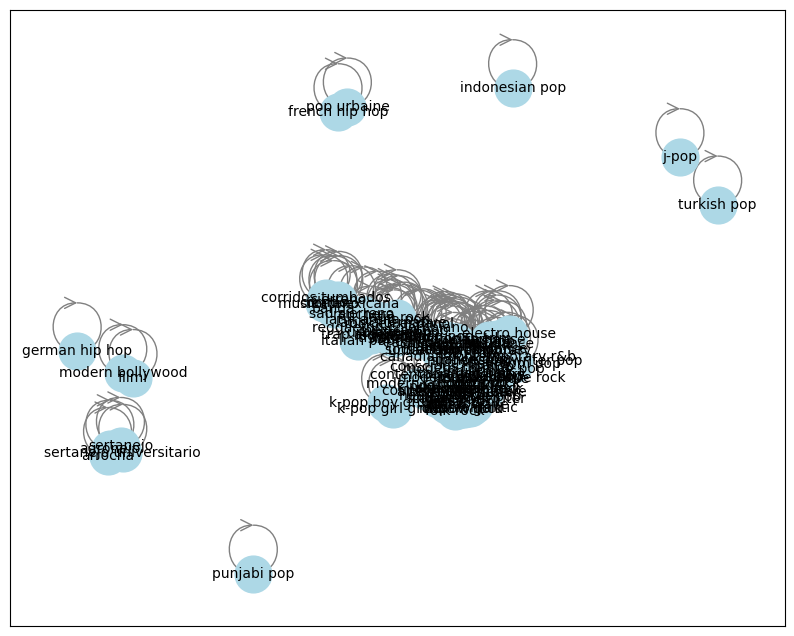

In [ ]:
from itertools import combinations
import networkx as nx
import matplotlib.pyplot as plt

# Assume query_genres is a list of 100 genres and genre_dict is a dictionary where
# the keys are genres and values are lists of tracks (each track is a list of genres)

# Initialize directed graph and adjacency matrix
directed_graph = nx.DiGraph()

# Step 1: Add nodes (parent nodes are from query_genres)
for genre in query_genres:
    directed_graph.add_node(genre)

# Step 2: Build directed edges from each playlist
for parent_genre in query_genres:
    if parent_genre in genre_dict:
        playlist_tracks = genre_dict[parent_genre]
        
        # For each track in the playlist, add directed edges between genre pairs
        for track in playlist_tracks:
            for i in range(len(track)):
                if track[i] in query_genres:
                    directed_graph.add_edge(parent_genre, track[i])
                # for j in range(i + 1, len(track)):  # Directed edge from genre i -> genre j
                #     genre1 = track[i]
                #     genre2 = track[j]
                    
                    # Only add edges if both genres are in query_genres
                    # if genre1 in query_genres and genre2 in query_genres:
                    #     directed_graph.add_edge(genre1, genre2)

# Step 3: Compute the directed adjacency matrix
n_genres = len(query_genres)
adjacency_matrix = np.zeros((n_genres, n_genres), dtype=int)

# Create a mapping of genre to index
genre_to_index = {genre: i for i, genre in enumerate(query_genres)}

# Populate the adjacency matrix
for genre1, genre2 in directed_graph.edges():
    i = genre_to_index[genre1]
    j = genre_to_index[genre2]
    adjacency_matrix[i, j] = 1  # Mark an adjacency between genre1 -> genre2

# Step 4: Visualize the directed adjacency matrix as a graph (optional)
plt.figure(figsize=(10, 8))

# Position nodes using a force-directed layout
pos = nx.spring_layout(directed_graph, seed=42)

# Draw nodes and edges
nx.draw_networkx_nodes(directed_graph, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_edges(directed_graph, pos, arrowstyle='->', arrowsize=20, edge_color='gray')

# Add labels for the nodes (genres)
nx.draw_networkx_labels(directed_graph, pos, font_size=10, font_color='black')

# Customize and display the plot
# plt.title('Directed Adjacency Graph of Genre Co-occurrences')
# plt.axis('off')
# plt.show()

# Step 5: Print or return the directed adjacency matrix
print("Directed Adjacency Matrix:")
print(adjacency_matrix)

In [145]:
for i, node in enumerate(directed_graph.nodes):
    print(i, node)

0 pop
1 rap
2 rock
3 urbano latino
4 hip hop
5 trap latino
6 reggaeton
7 dance pop
8 pop rap
9 modern rock
10 pov  indie
11 musica mexicana
12 latin pop
13 classic rock
14 filmi
15 permanent wave
16 trap
17 alternative metal
18 k-pop
19 r&b
20 corrido
21 canadian pop
22 norteno
23 sierreno
24 album rock
25 soft rock
26 pop dance
27 sad sierreno
28 edm
29 hard rock
30 contemporary country
31 mellow gold
32 uk pop
33 melodic rap
34 modern bollywood
35 alternative rock
36 banda
37 post-grunge
38 corridos tumbados
39 sertanejo universitario
40 nu metal
41 country
42 art pop
43 atl hip hop
44 urban contemporary
45 sertanejo
46 southern hip hop
47 singer-songwriter
48 reggaeton colombiano
49 arrocha
50 french hip hop
51 colombian pop
52 alt z
53 country road
54 mexican pop
55 canadian hip hop
56 j-pop
57 indonesian pop
58 singer-songwriter pop
59 ranchera
60 new wave pop
61 indietronica
62 german hip hop
63 pop urbaine
64 rock en espanol
65 latin alternative
66 gangster rap
67 soul
68 k-pop 

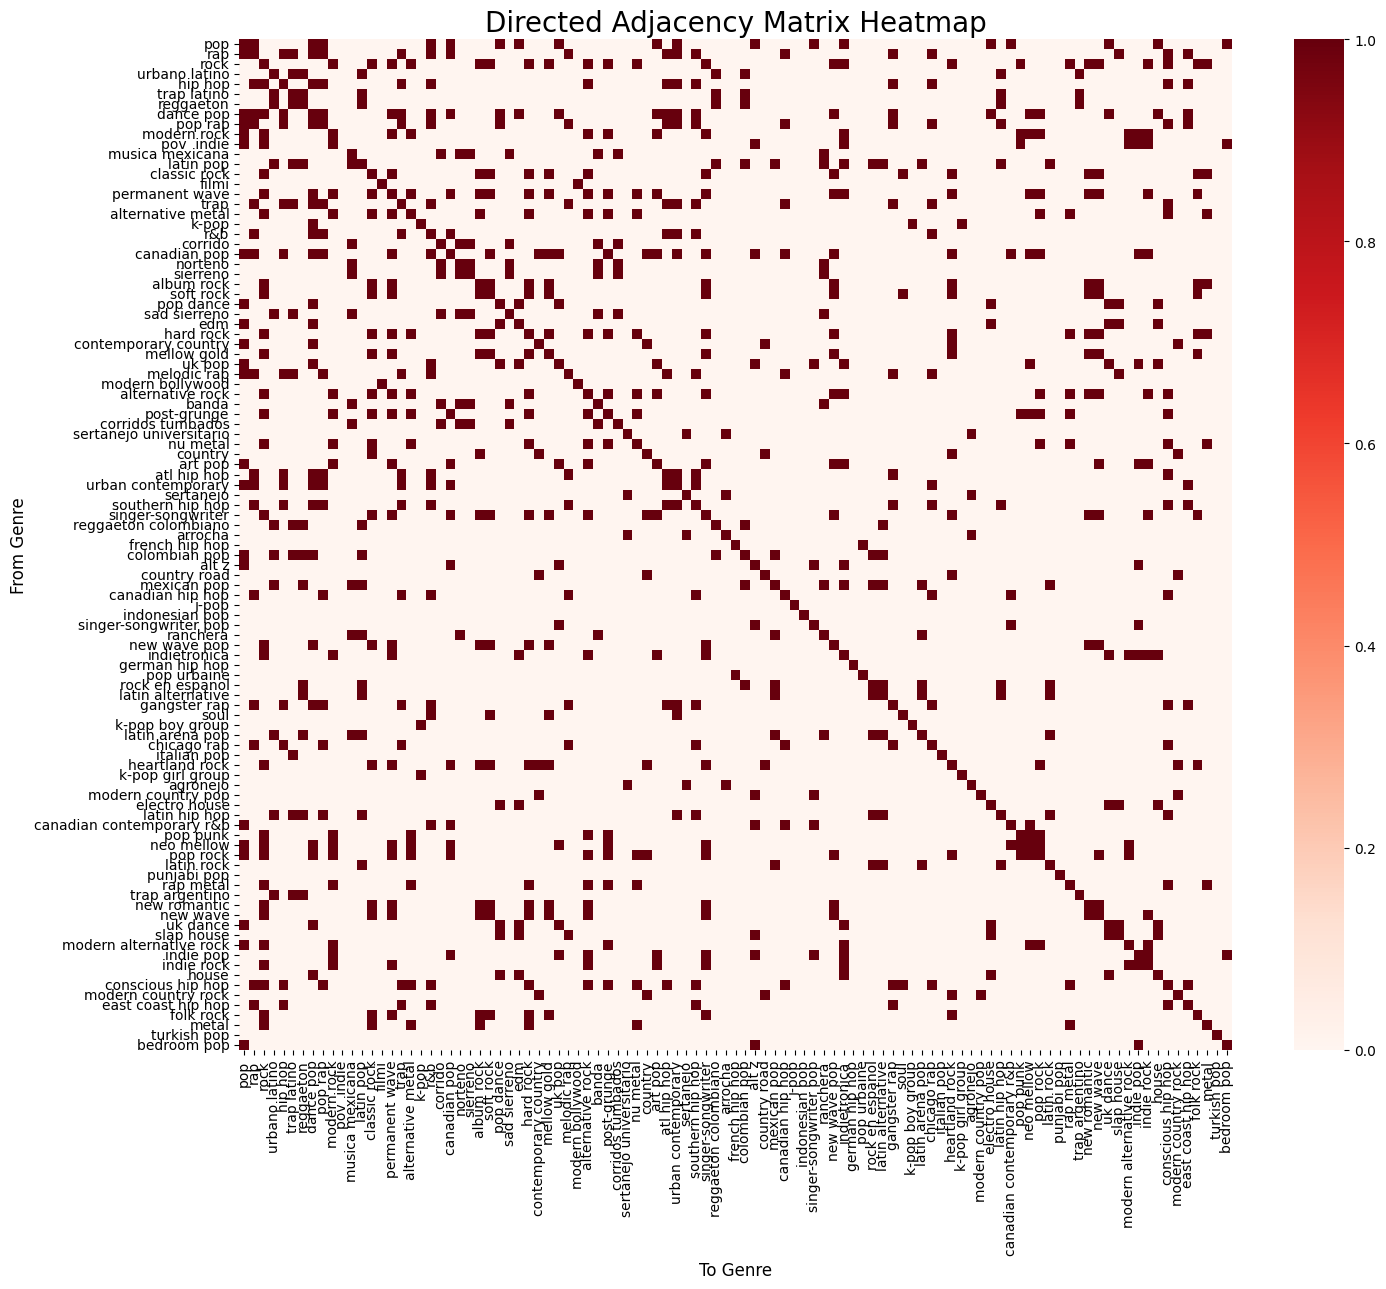

In [146]:
import seaborn as sns

# Assuming 'adjacency_matrix' and 'query_genres' are already defined

# Step 1: Create the heatmap
plt.figure(figsize=(15, 13))

# Use seaborn's heatmap function
sns.heatmap(adjacency_matrix, 
            xticklabels=query_genres, 
            yticklabels=query_genres, 
            cmap='Reds', 
            annot=False, 
            fmt="d")  # Format as integer

# Step 2: Customize the plot
plt.title('Directed Adjacency Matrix Heatmap', fontsize=20)

plt.xlabel('To Genre', fontsize=12)
plt.ylabel('From Genre', fontsize=12)

# Rotate tick labels for better readability
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# Step 3: Display the plot
plt.tight_layout()  # Adjusts plot to fit labels
plt.show()

In [1]:
from sklearn.manifold import TSNE

# Assume adj_matrix and unique_genres are computed from the previous code

# Step 1: Create a directed graph from the adjacency matrix
G = nx.DiGraph()

# Step 2: Add nodes (genres)
for genre in query_genres:
    G.add_node(genre)

# Step 3: Add directed edges based on the adjacency matrix
for i in range(len(query_genres)):
    for j in range(len(query_genres)):
        if adjacency_matrix[i, j] > 0 and i != j:  # If there's a directed edge
            G.add_edge(query_genres[i], query_genres[j], weight=adjacency_matrix[i, j])

# Step 4: Plot the directed graph
plt.figure(figsize=(20, 14))

# Position nodes using spring layout (force-directed layout)
pos = nx.spring_layout(G, seed=22, k=1/3)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=100, node_color='lightblue')

# Draw edges with arrows
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), arrowstyle='->', arrowsize=20, edge_color='gray')

# Add labels for nodes
label_options = {"ec": "k", "fc": "white", "alpha": 0.7}
nx.draw_networkx_labels(G, pos, labels={n: n for i, n in enumerate(G) if not i % 4 or n in ['filmi', 'modern bollywood']}, font_size=10, font_color='black', bbox=label_options)

# Draw edge labels (weights) if desired
# edge_labels = nx.get_edge_attributes(G, 'weight')
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

# Customize and display the plot
plt.title('Directed Adjacency Graph of Genre Co-occurrences in "Every Noise at Once" playlists')
plt.axis('off')  # Hide the axes
plt.show()

NameError: name 'nx' is not defined

In [89]:
edges = [
            tuple(edge)
            for edge in set(
                [
                    frozenset((a + 1, b + 1))
                    for a, row in enumerate(adjacency_matrix > 0)
                    for b, is_non_zero in enumerate(row)
                    if is_non_zero
                ]
            )
        ]

In [103]:
for a, row in enumerate(adjacency_matrix):
    for b, is_non_zero in enumerate(row):
        if is_non_zero and a == 85:
            print(frozenset((a+1, b+1)))

frozenset({4, 86})
frozenset({86, 6})
frozenset({86, 7})
frozenset({86})


In [94]:
out = [tuple(edge) for edge in set([frozenset((a+1, b+1)) for a, row in enumerate(adjacency_matrix > 0) for b, is_non_zero in enumerate(row) if is_non_zero])]
print(out)

[(8, 2), (86,), (75, 46), (91, 93), (1, 33), (34, 71), (89,), (81, 33), (67, 47), (60, 55), (17, 44), (16, 26), (9, 22), (33,), (48, 81), (24, 39), (9, 97), (9, 47), (20, 71), (24, 37), (45, 78), (13, 55), (2, 44), (30, 95), (41, 82), (29, 62), (16, 73), (77, 94), (8, 3), (21, 39), (32, 26), (97,), (4, 52), (41, 10), (96, 42), (33, 59), (12, 60), (52, 6), (74, 19), (49, 13), (36, 14), (80, 38), (88,), (66, 52), (65, 70), (81, 10), (98, 14), (48, 43), (76, 53), (44, 5), (83, 78), (18, 99), (25,), (1, 53), (50, 75), (96,), (56, 22), (9, 5), (73,), (11, 101), (85,), (73, 22), (8, 5), (28, 21), (34, 5), (32, 3), (53,), (26,), (51,), (75,), (87,), (5, 47), (15,), (9, 78), (38, 30), (45, 47), (48, 98), (97, 45), (68, 20), (4, 86), (16, 88), (99, 14), (42, 22), (62,), (56, 79), (92, 62), (2, 6), (85, 30), (44, 47), (10, 18), (85, 95), (90, 53), (91, 11), (32, 14), (89, 29), (69,), (92, 53), (41,), (101,), (25, 99), (61,), (17,), (67, 44), (80, 10), (3, 95), (29, 94), (99, 3), (38,), (7, 55), 

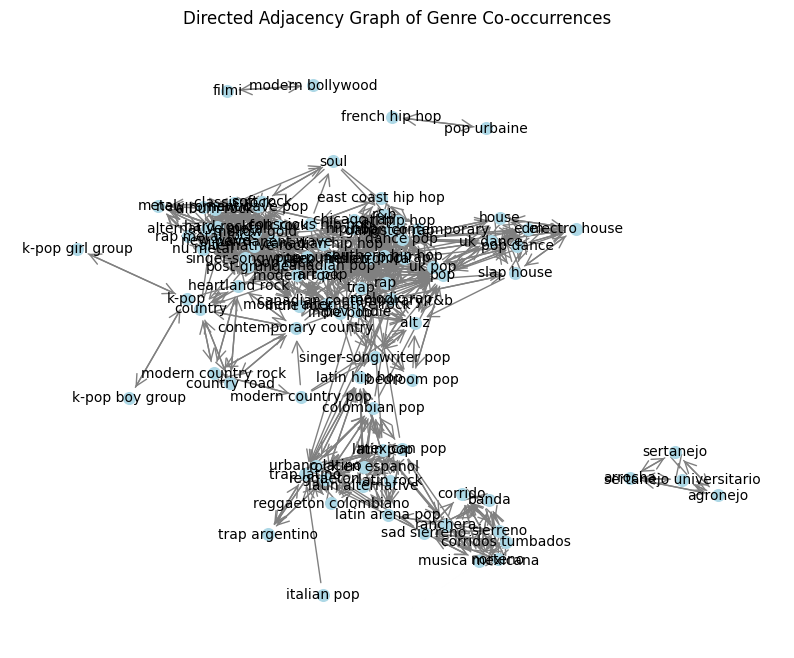

Directed Adjacency Matrix:
[[0 1 1 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [128]:
from itertools import combinations
import networkx as nx
import matplotlib.pyplot as plt

# Assume query_genres is a list of 100 genres and genre_dict is a dictionary where
# the keys are genres and values are lists of tracks (each track is a list of genres)

# Initialize directed graph and adjacency matrix
directed_graph = nx.DiGraph()

# Step 1: Add nodes (parent nodes are from query_genres)
# for genre in query_genres:
#     directed_graph.add_node(genre)

# Step 2: Build directed edges from each playlist
for parent_genre in query_genres:
    if parent_genre in genre_dict:
        playlist_tracks = genre_dict[parent_genre]
        
        # For each track in the playlist, add directed edges between genre pairs
        for track in playlist_tracks:
            for i in range(len(track)):
                if track[i] in query_genres and parent_genre != track[i]:
                    directed_graph.add_node(parent_genre)
                    directed_graph.add_edge(parent_genre, track[i])
                # for j in range(i + 1, len(track)):  # Directed edge from genre i -> genre j
                #     genre1 = track[i]
                #     genre2 = track[j]
                    
                    # Only add edges if both genres are in query_genres
                    # if genre1 in query_genres and genre2 in query_genres:
                    #     directed_graph.add_edge(genre1, genre2)

# Step 3: Compute the directed adjacency matrix
n_genres = len(directed_graph.nodes)
no_auto_adjacency_matrix = np.zeros((n_genres, n_genres), dtype=int)

# Create a mapping of genre to index
genre_to_index = {genre: i for i, genre in enumerate(directed_graph.nodes)}

# Populate the adjacency matrix
for genre1, genre2 in directed_graph.edges():
    i = genre_to_index[genre1]
    j = genre_to_index[genre2]
    no_auto_adjacency_matrix[i, j] = 1  # Mark an adjacency between genre1 -> genre2

# Step 4: Visualize the directed adjacency matrix as a graph (optional)
plt.figure(figsize=(10, 8))

# Position nodes using a force-directed layout
pos = nx.spring_layout(directed_graph, seed=42, k=1/3)

# Draw nodes and edges
nx.draw_networkx_nodes(directed_graph, pos, node_size=70, node_color='lightblue')
nx.draw_networkx_edges(directed_graph, pos, arrowstyle='->', arrowsize=20, edge_color='gray')

# Add labels for the nodes (genres)
nx.draw_networkx_labels(directed_graph, pos, font_size=10, font_color='black')

# Customize and display the plot
plt.title('Directed Adjacency Graph of Genre Co-occurrences')
plt.axis('off')
plt.show()

# Step 5: Print or return the directed adjacency matrix
print("Directed Adjacency Matrix:")
print(no_auto_adjacency_matrix)




In [129]:
np.save("no_auto_adjacency.npy", no_auto_adjacency_matrix)

In [127]:
genre_to_index

{'pop': 0,
 'rap': 1,
 'rock': 2,
 'urbano latino': 3,
 'hip hop': 4,
 'trap latino': 5,
 'reggaeton': 6,
 'dance pop': 7,
 'pop rap': 8,
 'modern rock': 9,
 'pov  indie': 10,
 'musica mexicana': 11,
 'latin pop': 12,
 'classic rock': 13,
 'filmi': 14,
 'permanent wave': 15,
 'trap': 16,
 'alternative metal': 17,
 'k-pop': 18,
 'r&b': 19,
 'corrido': 20,
 'canadian pop': 21,
 'norteno': 22,
 'sierreno': 23,
 'album rock': 24,
 'soft rock': 25,
 'pop dance': 26,
 'sad sierreno': 27,
 'edm': 28,
 'hard rock': 29,
 'contemporary country': 30,
 'mellow gold': 31,
 'uk pop': 32,
 'melodic rap': 33,
 'modern bollywood': 34,
 'alternative rock': 35,
 'banda': 36,
 'post-grunge': 37,
 'corridos tumbados': 38,
 'sertanejo universitario': 39,
 'nu metal': 40,
 'country': 41,
 'art pop': 42,
 'atl hip hop': 43,
 'urban contemporary': 44,
 'sertanejo': 45,
 'southern hip hop': 46,
 'singer-songwriter': 47,
 'reggaeton colombiano': 48,
 'arrocha': 49,
 'french hip hop': 50,
 'colombian pop': 51,
 '

In [115]:
print([row for row in no_auto_adjacency_matrix if max(row) == 0])

[array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0,

In [134]:
if os.path.isdir("ckpt33"):
    paths = [
        os.path.join("ckpt33", c)
        for c in os.listdir("ckpt33")
        if c.endswith("ckpt33")
    ]

In [2]:
os.listdir("ckpt33")

NameError: name 'os' is not defined

In [2]:
import numpy as np
depth = 5
N = sum(2 ** i for i in range(depth))
mat = np.zeros((N, N))
for i in range(N):
    j = 2 * i + 1
    if j + 1 >= N:
        break
    mat[i, j] = 1
    mat[i, j + 1] = 1
binary_tree = mat

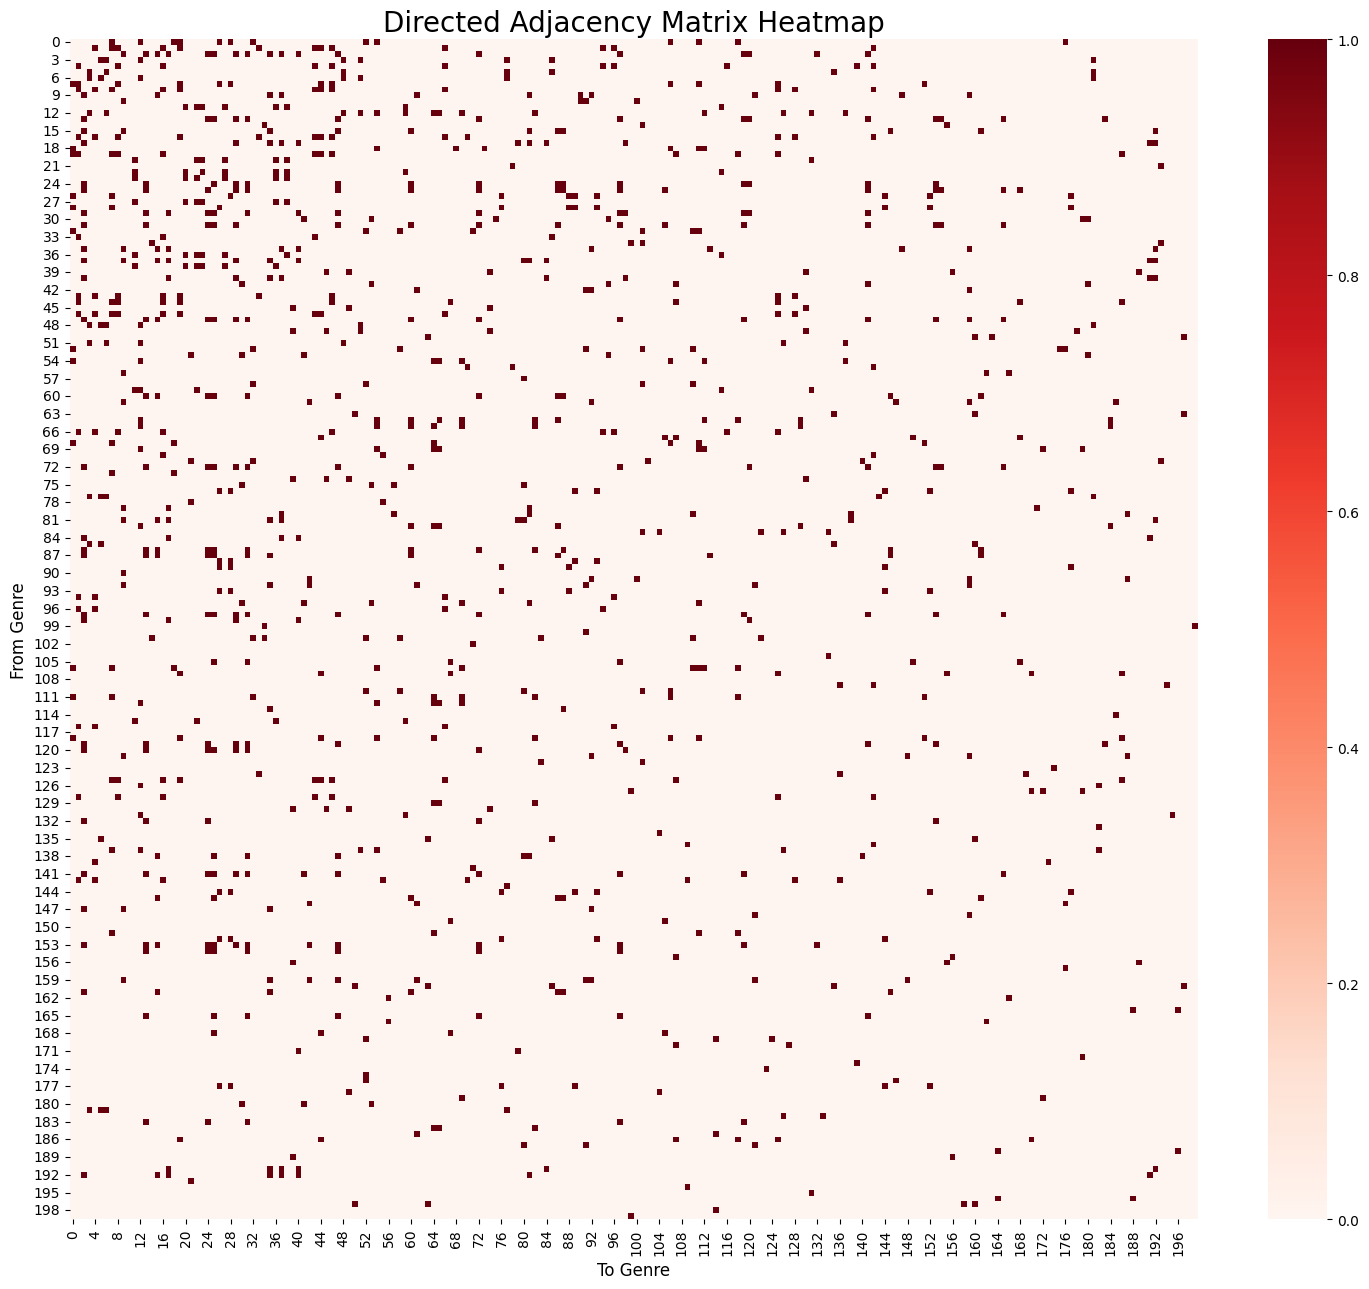

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 13))

# Use seaborn's heatmap function
sns.heatmap(adjacency_matrix[:200, :200], 
            cmap='Reds', 
            annot=False, 
            fmt="d")  # Format as integer

# Step 2: Customize the plot
plt.title('Directed Adjacency Matrix Heatmap', fontsize=20)

plt.xlabel('To Genre', fontsize=12)
plt.ylabel('From Genre', fontsize=12)

# Rotate tick labels for better readability
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# Step 3: Display the plot
plt.tight_layout()  # Adjusts plot to fit labels
plt.show()

In [1]:
adjacency_matrix

NameError: name 'adjacency_matrix' is not defined